Loading datasets...
Training Set Shape: (147613, 51)
Testing Set Shape:  (63267, 51)

Preprocessing and encoding categorical features...
Features after encoding: 64

SIMULATING SEMI-SUPERVISED ENVIRONMENT
Total Training Samples: 147613
Labeled Samples Retained: 29569 (20%)
Unlabeled Samples (-1): 118044 (80%)

Treinando classificador binário (Self-Training RF)
Fazendo fit no modelo...
End of iteration 1, added 55215 new labels.
End of iteration 2, added 16782 new labels.
End of iteration 3, added 8424 new labels.
End of iteration 4, added 5334 new labels.
End of iteration 5, added 3748 new labels.
End of iteration 6, added 2838 new labels.
End of iteration 7, added 2118 new labels.
End of iteration 8, added 1589 new labels.
End of iteration 9, added 1337 new labels.
End of iteration 10, added 1142 new labels.

Predizendo no conjunto de teste...

--- Relatório - Classe Binária ---
              precision    recall  f1-score   support

  Normal (0)       0.71      0.88      0.79     3035

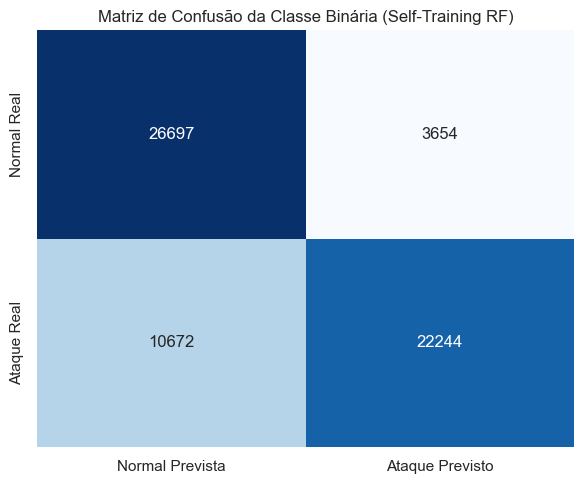


Treinando o Classificador Multi-Classe (Self-Training RF)
Fazendo fit no modelo...
End of iteration 1, added 51034 new labels.
End of iteration 2, added 15509 new labels.
End of iteration 3, added 7984 new labels.
End of iteration 4, added 5756 new labels.
End of iteration 5, added 4409 new labels.
End of iteration 6, added 3524 new labels.
End of iteration 7, added 2757 new labels.
End of iteration 8, added 2195 new labels.
End of iteration 9, added 1779 new labels.
End of iteration 10, added 1327 new labels.

Predizendo no conjunto de teste...

--- Relatório - Multiclasse ---
                precision    recall  f1-score   support

      Analysis       0.35      0.03      0.06      3990
           DoS       1.00      1.00      1.00     11847
      Exploits       0.96      0.15      0.26      8192
       Fuzzers       0.36      0.11      0.17      4085
        Normal       0.66      0.98      0.79     30351
Reconnaissance       0.93      0.70      0.80      4802

      accuracy      

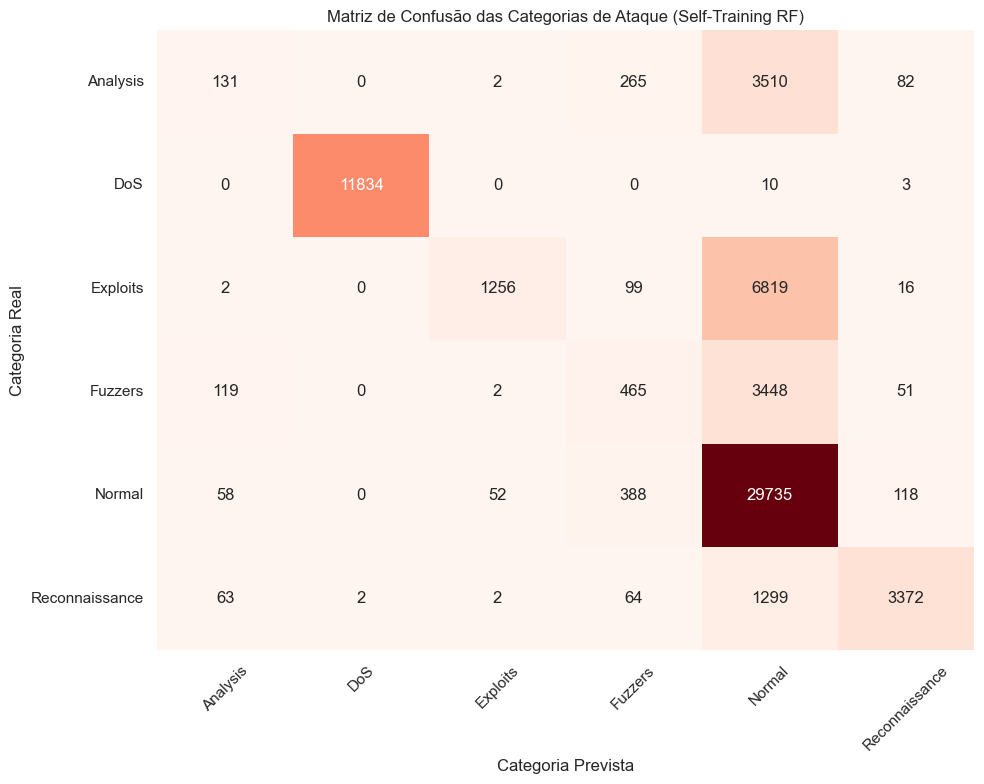


Top 10 Features Mais Importantes (Extraídas do RF Base)


AttributeError: 'SelfTrainingClassifier' object has no attribute 'base_estimator_'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape:  {test_df.shape}")

# ==========================================
# 2. DATA PREPROCESSING & ENCODING
# ==========================================
print("\nPreprocessing and encoding categorical features...")

targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']
drop_cols = targets + identities

# Separate features (X) and targets (y)
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label'].values
y_train_multi = train_df['attack_cat'].values

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label'].values
y_test_multi = test_df['attack_cat'].values

cat_cols = ['proto', 'service', 'state']

X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Encode multi-class strings to integers for the SelfTrainingClassifier
label_encoder = LabelEncoder()
y_train_multi_encoded = label_encoder.fit_transform(y_train_multi)
y_test_multi_encoded = label_encoder.transform(y_test_multi)
class_names = label_encoder.classes_

print(f"Features after encoding: {X_train_encoded.shape[1]}")

# ==========================================
# 2.5 SIMULATE UNLABELED DATA (SEMI-SUPERVISED MASKING)
# ==========================================
print("\n" + "="*50)
print("SIMULATING SEMI-SUPERVISED ENVIRONMENT")
print("="*50)

mask_percentage = 0.80 # Hide 80% of the training labels
rng = np.random.RandomState(42)

# Create masks (True = hide this label)
random_unlabeled_points_bin = rng.rand(len(y_train_bin)) < mask_percentage
random_unlabeled_points_multi = rng.rand(len(y_train_multi_encoded)) < mask_percentage

# Apply -1 to the hidden data points (sklearn's universal "unlabeled" marker)
y_train_bin_masked = np.copy(y_train_bin)
y_train_bin_masked[random_unlabeled_points_bin] = -1

y_train_multi_masked = np.copy(y_train_multi_encoded)
y_train_multi_masked[random_unlabeled_points_multi] = -1

print(f"Total Training Samples: {len(y_train_bin)}")
print(f"Labeled Samples Retained: {len(y_train_bin) - random_unlabeled_points_bin.sum()} ({(1-mask_percentage)*100:.0f}%)")
print(f"Unlabeled Samples (-1): {random_unlabeled_points_bin.sum()} ({mask_percentage*100:.0f}%)")

# ==========================================
# 3. BINARY CLASSIFICATION (Attack vs Normal)
# ==========================================
print("\n" + "="*50)
print("Treinando classificador binário (Self-Training RF)")
print("="*50)

# The base estimator to be used inside the Self-Training loop
base_rf_bin = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# Initialize SelfTrainingClassifier. 
# threshold=0.8 means the RF must be 80% confident to pseudo-label an unlabeled point.
st_clf_bin = SelfTrainingClassifier(base_rf_bin, threshold=0.80, verbose=True)

print("Fazendo fit no modelo...")
st_clf_bin.fit(X_train_encoded, y_train_bin_masked)

print("\nPredizendo no conjunto de teste...")
y_pred_bin = st_clf_bin.predict(X_test_encoded)

# Binary Metrics
print("\n--- Relatório - Classe Binária ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque (1)']))

# Binary Confusion Matrix
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal Prevista', 'Ataque Previsto'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão da Classe Binária (Self-Training RF)')
plt.tight_layout()
plt.show()

# ==========================================
# 4. MULTI-CLASS CLASSIFICATION (Attack Categories)
# ==========================================
print("\n" + "="*50)
print("Treinando o Classificador Multi-Classe (Self-Training RF)")
print("="*50)

base_rf_multi = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

st_clf_multi = SelfTrainingClassifier(base_rf_multi, threshold=0.80, verbose=True)

print("Fazendo fit no modelo...")
st_clf_multi.fit(X_train_encoded, y_train_multi_masked)

print("\nPredizendo no conjunto de teste...")
y_pred_multi_encoded = st_clf_multi.predict(X_test_encoded)

y_pred_multi = label_encoder.inverse_transform(y_pred_multi_encoded)

# Multi-Class Metrics
print("\n--- Relatório - Multiclasse ---")
print(classification_report(y_test_multi, y_pred_multi, target_names=class_names))

# Multi-Class Confusion Matrix
plt.figure(figsize=(10, 8))
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=class_names)

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão das Categorias de Ataque (Self-Training RF)')
plt.xlabel('Categoria Prevista')
plt.ylabel('Categoria Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE
# ==========================================
print("\n" + "="*50)
print("Top 10 Features Mais Importantes (Extraídas do RF Base)")
print("="*50)

# Extract the fitted base estimator from the SelfTraining wrapper
fitted_rf = st_clf_multi.base_estimator_

feature_importances = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importancia': fitted_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(feature_importances.head(10).to_string(index=False))